<a href="https://colab.research.google.com/github/ariandit/user_arian/blob/master/deeplearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# Cell 1 — Install & import
# =========================
!pip install -q kagglehub

import kagglehub
import os
import zipfile
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
print("Imports OK. TensorFlow version:", tf.__version__)

Imports OK. TensorFlow version: 2.19.0


In [ ]:
# =========================
# Cell 2 — Download dataset via kagglehub
# =========================
path = kagglehub.dataset_download("sriramr/fruits-fresh-and-rotten-for-classification")
print("kagglehub returned path:", path)

def find_dataset_root(p):
    if os.path.isfile(p) and p.lower().endswith('.zip'):
        extract_to = "/content/dataset_from_kaggle"
        os.makedirs(extract_to, exist_ok=True)
        print("Extracting zip:", p, "->", extract_to)
        with zipfile.ZipFile(p, 'r') as z:
            z.extractall(extract_to)
        return extract_to
    if os.path.isdir(p):
        items = os.listdir(p)
        lower_items = [x.lower() for x in items]
        if 'fresh' in lower_items and 'rotten' in lower_items:
            return p

        for item in items:
            candidate = os.path.join(p, item)
            if os.path.isdir(candidate):
                subitems = [name.lower() for name in os.listdir(candidate)]
                if 'fresh' in subitems and 'rotten' in subitems:
                    return candidate

        if 'train' in lower_items or 'test' in lower_items:
            return p
    return p

data_root = find_dataset_root(path)
if os.path.isdir(os.path.join(path, "dataset")) and os.listdir(os.path.join(path,"dataset")):
    data_root = os.path.join(path, "dataset")

print("Resolved data_root:", data_root)
print("Contents (sample):", os.listdir(data_root)[:10])

Using Colab cache for faster access to the 'fruits-fresh-and-rotten-for-classification' dataset.
kagglehub returned path: /kaggle/input/fruits-fresh-and-rotten-for-classification
Resolved data_root: /kaggle/input/fruits-fresh-and-rotten-for-classification/dataset
Contents (sample): ['dataset', 'test', 'train']


In [ ]:
# =========================
# Cell 3 — Determine dataset dir & extract if needed
# =========================

def find_dataset_root(p):
    # if p is a file and a zip -> extract to /content/dataset_unzip
    if os.path.isfile(p) and p.lower().endswith('.zip'):
        extract_to = "/content/dataset_from_kaggle"
        os.makedirs(extract_to, exist_ok=True)
        print("Extracting zip:", p, "->", extract_to)
        with zipfile.ZipFile(p, 'r') as z:
            z.extractall(extract_to)
        return extract_to

        items = os.listdir(p)

        lower_items = [x.lower() for x in items]

        if 'fresh' in lower_items and 'rotten' in lower_items:
            return p

        for item in items:
            candidate = os.path.join(p, item)
            if os.path.isdir(candidate):
                subitems = [name.lower() for name in os.listdir(candidate)]
                if 'fresh' in subitems and 'rotten' in subitems:
                    return candidate

        if 'train' in lower_items or 'test' in lower_items:
            return p
    return p

data_root = os.path.join(path, "dataset")

print("Force corrected root:", data_root)
print("Contents:", os.listdir(data_root))


Force corrected root: /root/.cache/kagglehub/datasets/sriramr/fruits-fresh-and-rotten-for-classification/versions/1/dataset
Contents: ['dataset', 'train', 'test']


In [ ]:
# =========================
# Cell 4 (UPDATED) — Build generators for 6 Classes
# =========================
img_size = (224, 224)
batch_size = 32
seed = 42

# Setup Augmentasi Data
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=30,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale=1./255)

# Load Data Training (Pastikan path 'data_root' menunjuk ke folder yang berisi 'train' dan 'test')
train_dir = os.path.join(data_root, 'train')
test_dir = os.path.join(data_root, 'test')

print(f"Loading train from: {train_dir}")
print(f"Loading test from: {test_dir}")

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical', # MengUbah ke categorical
    shuffle=True,
    seed=seed
)

val_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical', # MengUbah ke categorical
    shuffle=False, # false untuk evaluasi yang benar
    seed=seed
)

print("Classes dictionary:", train_data.class_indices)

Loading train from: /kaggle/input/fruits-fresh-and-rotten-for-classification/dataset/train
Loading test from: /kaggle/input/fruits-fresh-and-rotten-for-classification/dataset/test
Found 10901 images belonging to 6 classes.
Found 2698 images belonging to 6 classes.
Classes dictionary: {'freshapples': 0, 'freshbanana': 1, 'freshoranges': 2, 'rottenapples': 3, 'rottenbanana': 4, 'rottenoranges': 5}


In [ ]:
# =========================
# Cell 5 (UPDATED) — Build Multi-class CNN model
# =========================
num_classes = len(train_data.class_indices) if hasattr(train_data, "class_indices") else 6 # fallback

model = models.Sequential([
    layers.Input(shape=(img_size[0], img_size[1], 3)),

    # Blok Konvolusi
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5), # Mencegah overfitting

    # OUTPUT LAYER : num_classes neuron, activation='softmax'
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,681,606 (36.93 MB)

 Trainable params: 9,681,606 (36.93 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =========================
# Cell 6 — Callbacks & Train
# =========================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
    ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)
]

epochs = 12
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=epochs,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 0.4611 - loss: 1.3659

341/341 ━━━━━━━━━━━━━━━━━━━━ 247s 698ms/step - accuracy: 0.4616 - loss: 1.3648 - val_accuracy: 0.8751 - val_loss: 0.3905 - learning_rate: 0.0010
Epoch 2/12
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.8274 - loss: 0.4864

341/341 ━━━━━━━━━━━━━━━━━━━━ 174s 512ms/step - accuracy: 0.8274 - loss: 0.4863 - val_accuracy: 0.9114 - val_loss: 0.2666 - learning_rate: 0.0010
Epoch 3/12
341/341 ━━━━━━━━━━━━━━━━━━━━ 176s 516ms/step - accuracy: 0.8719 - loss: 0.3592 - val_accuracy: 0.8873 - val_loss: 0.3042 - learning_rate: 0.0010
Epoch 4/12
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.8860 - loss: 0.3158

341/341 ━━━━━━━━━━━━━━━━━━━━ 173s 508ms/step - accuracy: 0.8860 - loss: 0.3158 - val_accuracy: 0.9103 - val_loss: 0.2494 - learning_rate: 0.0010
Epoch 5/12
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.8962 - loss: 0.2804

341/341 ━━━━━━━━━━━━━━━━━━━━ 174s 509ms/step - accuracy: 0.8962 - loss: 0.2804 - val_accuracy: 0.9466 - val_loss: 0.1519 - learning_rate: 0.0010
Epoch 6/12
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.9142 - loss: 0.2361

341/341 ━━━━━━━━━━━━━━━━━━━━ 175s 512ms/step - accuracy: 0.9142 - loss: 0.2361 - val_accuracy: 0.9555 - val_loss: 0.1311 - learning_rate: 0.0010
Epoch 7/12
341/341 ━━━━━━━━━━━━━━━━━━━━ 174s 510ms/step - accuracy: 0.9145 - loss: 0.2380 - val_accuracy: 0.9451 - val_loss: 0.1625 - learning_rate: 0.0010
Epoch 8/12
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.9202 - loss: 0.2166

341/341 ━━━━━━━━━━━━━━━━━━━━ 173s 507ms/step - accuracy: 0.9202 - loss: 0.2166 - val_accuracy: 0.9622 - val_loss: 0.1054 - learning_rate: 0.0010
Epoch 9/12
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.9273 - loss: 0.1988

341/341 ━━━━━━━━━━━━━━━━━━━━ 173s 508ms/step - accuracy: 0.9273 - loss: 0.1988 - val_accuracy: 0.9640 - val_loss: 0.0958 - learning_rate: 0.0010
Epoch 10/12
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.9333 - loss: 0.1889

341/341 ━━━━━━━━━━━━━━━━━━━━ 177s 518ms/step - accuracy: 0.9333 - loss: 0.1889 - val_accuracy: 0.9752 - val_loss: 0.0680 - learning_rate: 0.0010
Epoch 11/12
341/341 ━━━━━━━━━━━━━━━━━━━━ 175s 512ms/step - accuracy: 0.9404 - loss: 0.1706 - val_accuracy: 0.9774 - val_loss: 0.0681 - learning_rate: 0.0010
Epoch 12/12
341/341 ━━━━━━━━━━━━━━━━━━━━ 178s 522ms/step - accuracy: 0.9459 - loss: 0.1506 - val_accuracy: 0.9703 - val_loss: 0.0820 - learning_rate: 0.0010


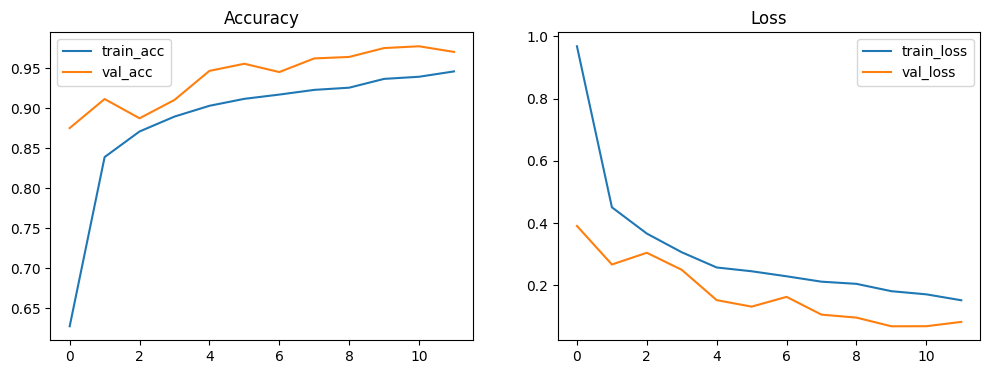

In [ ]:
# =========================
# Cell 7 — Plots
# =========================
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history.get('accuracy',[]), label='train_acc')
plt.plot(history.history.get('val_accuracy',[]), label='val_acc')
plt.legend(); plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history.get('loss',[]), label='train_loss')
plt.plot(history.history.get('val_loss',[]), label='val_loss')
plt.legend(); plt.title('Loss')
plt.show()

In [ ]:
# =========================
# Cell 8 (UPDATED) — Evaluation for Multi-Class
# =========================
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Ambil label asli
y_true = val_data.classes

# Prediksi model utama
predictions = model.predict(val_data, verbose=1)
y_pred = np.argmax(predictions, axis=1) # mengambil index nilai tertinggi

# Tampilkan Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

# Tampilkan Laporan Lengkap
class_labels = list(val_data.class_indices.keys())
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

85/85 ━━━━━━━━━━━━━━━━━━━━ 18s 201ms/step
Confusion Matrix:
[[378   0   2  15   0   0]
 [  0 375   0   4   1   1]
 [  0   0 369   5   0  14]
 [  2   0   3 589   1   6]
 [  0   1   0   0 529   0]
 [  0   0   5   7   0 391]]

Classification Report:
               precision    recall  f1-score   support

  freshapples       0.99      0.96      0.98       395
  freshbanana       1.00      0.98      0.99       381
 freshoranges       0.97      0.95      0.96       388
 rottenapples       0.95      0.98      0.96       601
 rottenbanana       1.00      1.00      1.00       530
rottenoranges       0.95      0.97      0.96       403

     accuracy                           0.98      2698
    macro avg       0.98      0.97      0.97      2698
 weighted avg       0.98      0.98      0.98      2698



In [ ]:
# =========================
# Cell 9 — Save model
# =========================
model.save('/content/fruit_freshness_binary.h5')
print("Model saved to /content/fruit_freshness_binary.h5")

Model saved to /content/fruit_freshness_binary.h5


In [ ]:
# =========================
# Cell 10 — (Fitur Tambahan) Baseline Model: MobileNetV2 Frozen (sebagai pembanding)
# =========================
# Tidak mengubah model utama. Hanya evaluasi baseline pre-trained (frozen).
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Buat datagen untuk baseline yang sesuai preprocessing MobileNetV2
baseline_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

baseline_val = baseline_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


from tensorflow.keras import Model, Input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

mob_base = MobileNetV2(include_top=False, weights='imagenet', input_shape=(img_size[0], img_size[1],3))
mob_base.trainable = False  # frozen

x = mob_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
preds = Dense(num_classes, activation='softmax')(x)

baseline_model = Model(inputs=mob_base.input, outputs=preds)
baseline_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
baseline_model.summary()

# tidak melatih baseline_model (frozen backbone), hanya lakukan prediksi langsung.
baseline_predictions = baseline_model.predict(baseline_val, verbose=1)
baseline_pred_labels = np.argmax(baseline_predictions, axis=1)

print("\n=== BASELINE (MobileNetV2 frozen) - Confusion Matrix ===")
print(confusion_matrix(y_true, baseline_pred_labels))
print("\n=== BASELINE (MobileNetV2 frozen) - Classification Report ===")
print(classification_report(y_true, baseline_pred_labels, target_names=class_labels))

Found 2698 images belonging to 6 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


85/85 ━━━━━━━━━━━━━━━━━━━━ 36s 278ms/step

=== BASELINE (MobileNetV2 frozen) - Confusion Matrix ===
[[  9  62 287  18  10   9]
 [  1  43 324   6   0   7]
 [ 13  90 246  24  13   2]
 [ 23  47 421  50  19  41]
 [ 13  56 427  10   0  24]
 [ 16 100 230  14  14  29]]

=== BASELINE (MobileNetV2 frozen) - Classification Report ===
               precision    recall  f1-score   support

  freshapples       0.12      0.02      0.04       395
  freshbanana       0.11      0.11      0.11       381
 freshoranges       0.13      0.63      0.21       388
 rottenapples       0.41      0.08      0.14       601
 rottenbanana       0.00      0.00      0.00       530
rottenoranges       0.26      0.07      0.11       403

     accuracy                           0.14      2698
    macro avg       0.17      0.15      0.10      2698
 weighted avg       0.18      0.14      0.10      2698



In [ ]:
# =========================
# Cell 11 — (Fitur Tambahan)Metrik Evaluasi Tambahan untuk Model Utama
# =========================
from sklearn.metrics import precision_score, recall_score, f1_score, top_k_accuracy_score

# Macro metrics
macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
macro_recall    = recall_score(y_true, y_pred, average='macro', zero_division=0)
macro_f1        = f1_score(y_true, y_pred, average='macro', zero_division=0)

# Top-2 accuracy (berguna untuk multi-class)
top2_acc = top_k_accuracy_score(y_true, predictions, k=2)

print("\n=== METRIK TAMBAHAN MODEL UTAMA ===")
print("Macro Precision :", macro_precision)
print("Macro Recall    :", macro_recall)
print("Macro F1-score  :", macro_f1)
print("Top-2 Accuracy  :", top2_acc)

# Metrik baseline juga
baseline_macro_precision = precision_score(y_true, baseline_pred_labels, average='macro', zero_division=0)
baseline_macro_recall    = recall_score(y_true, baseline_pred_labels, average='macro', zero_division=0)
baseline_macro_f1        = f1_score(y_true, baseline_pred_labels, average='macro', zero_division=0)
baseline_top2_acc = top_k_accuracy_score(y_true, baseline_predictions, k=2)

print("\n=== METRIK TAMBAHAN BASELINE ===")
print("Baseline Macro Precision :", baseline_macro_precision)
print("Baseline Macro Recall    :", baseline_macro_recall)
print("Baseline Macro F1-score  :", baseline_macro_f1)
print("Baseline Top-2 Accuracy  :", baseline_top2_acc)


=== METRIK TAMBAHAN MODEL UTAMA ===
Macro Precision : 0.976825781872269
Macro Recall    : 0.9734357886891442
Macro F1-score  : 0.9749819735463437
Top-2 Accuracy  : 0.9988880652335063

=== METRIK TAMBAHAN BASELINE ===
Baseline Macro Precision : 0.17065610349218394
Baseline Macro Recall    : 0.15413688239654158
Baseline Macro F1-score  : 0.1019041427744251
Baseline Top-2 Accuracy  : 0.3510007412898443


In [ ]:
# =========================
# Cell 12 — (Fitur Tambahan)Eksperimen Model Tambahan (Improved CNN ringan)
# =========================
improved_model = models.Sequential([
    layers.Input(shape=(img_size[0], img_size[1], 3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Tambahan layer ringan yang tidak mengubah secara drastis
    layers.Conv2D(96, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

improved_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(improved_model.summary())

# Pelatihan singkat (epoch sedikit supaya cepat)
improved_history = improved_model.fit(
    train_data,
    validation_data=val_data,
    epochs=6,
    verbose=1
)

# Prediksi improved model
imp_pred = improved_model.predict(val_data, verbose=1)
imp_pred_label = np.argmax(imp_pred, axis=1)

print("\n=== CLASSIFICATION REPORT (Improved Model) ===")
print(classification_report(y_true, imp_pred_label, target_names=class_labels))

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 128)    │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,626,278 (36.72 MB)

 Trainable params: 9,626,278 (36.72 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/6
341/341 ━━━━━━━━━━━━━━━━━━━━ 184s 525ms/step - accuracy: 0.5321 - loss: 1.1582 - val_accuracy: 0.8606 - val_loss: 0.4270
Epoch 2/6
341/341 ━━━━━━━━━━━━━━━━━━━━ 175s 512ms/step - accuracy: 0.8200 - loss: 0.5054 - val_accuracy: 0.8996 - val_loss: 0.2644
Epoch 3/6
341/341 ━━━━━━━━━━━━━━━━━━━━ 173s 508ms/step - accuracy: 0.8585 - loss: 0.4063 - val_accuracy: 0.9199 - val_loss: 0.2158
Epoch 4/6
341/341 ━━━━━━━━━━━━━━━━━━━━ 173s 508ms/step - accuracy: 0.8797 - loss: 0.3377 - val_accuracy: 0.9329 - val_loss: 0.1758
Epoch 5/6
341/341 ━━━━━━━━━━━━━━━━━━━━ 176s 515ms/step - accuracy: 0.9013 - loss: 0.2743 - val_accuracy: 0.9388 - val_loss: 0.1746
Epoch 6/6
341/341 ━━━━━━━━━━━━━━━━━━━━ 174s 510ms/step - accuracy: 0.9059 - loss: 0.2615 - val_accuracy: 0.9496 - val_loss: 0.1315
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 146ms/step

=== CLASSIFICATION REPORT (Improved Model) ===
               precision    recall  f1-score   support

  freshapples       0.89      0.98      0.93       395
  freshb

In [ ]:
# =========================
# Cell 13 — (Fitur Tambahan) Evaluasi Perbandingan Ringkas
# =========================
print("\n=== PERBANDINGAN SINGKAT ===")
# Ambil val accuracies dari history (jika ada)
main_val_acc = history.history.get('val_accuracy', [None])[-1]
improved_val_acc = improved_history.history.get('val_accuracy', [None])[-1]
baseline_val_acc = (baseline_pred_labels == y_true).mean()

print(f"Model Utama val_accuracy (terakhir): {main_val_acc}")
print(f"Improved Model val_accuracy (terakhir): {improved_val_acc}")
print(f"Baseline (MobileNetV2 frozen) Top-1 Accuracy: {baseline_val_acc:.4f}")

# Tampilkan metrik utama per model
from sklearn.metrics import accuracy_score

print("\n--- Ringkasan metrics per model ---")
print("Main Model Accuracy (on val set):", accuracy_score(y_true, y_pred))
print("Baseline Model Accuracy (on val set):", accuracy_score(y_true, baseline_pred_labels))
print("Improved Model Accuracy (on val set):", accuracy_score(y_true, imp_pred_label))

# Cetak macro-F1 per model
print("\nMacro-F1 main model :", f1_score(y_true, y_pred, average='macro', zero_division=0))
print("Macro-F1 baseline    :", f1_score(y_true, baseline_pred_labels, average='macro', zero_division=0))
print("Macro-F1 improved    :", f1_score(y_true, imp_pred_label, average='macro', zero_division=0))


=== PERBANDINGAN SINGKAT ===
Model Utama val_accuracy (terakhir): 0.9703484177589417
Improved Model val_accuracy (terakhir): 0.9495922923088074
Baseline (MobileNetV2 frozen) Top-1 Accuracy: 0.1397

--- Ringkasan metrics per model ---
Main Model Accuracy (on val set): 0.9751667902149741
Baseline Model Accuracy (on val set): 0.1397331356560415
Improved Model Accuracy (on val set): 0.949592290585619

Macro-F1 main model : 0.9749819735463437
Macro-F1 baseline    : 0.1019041427744251
Macro-F1 improved    : 0.94949517759573


In [ ]:
# =========================
# Cell 14 — (Fitur Tambahan) Simpan artefak hasil perbandingan
# =========================
# Simpan model improved dan baseline (opsional)
improved_model.save('/content/fruit_improved_model.h5')
baseline_model.save('/content/fruit_baseline_mobilenetv2_frozen.h5')

# Simpan ringkasan metrik ke CSV
import pandas as pd

summary = {
    "model": ["main_model", "baseline_mobilenetv2_frozen", "improved_model"],
    "accuracy": [
        float(accuracy_score(y_true, y_pred)),
        float(accuracy_score(y_true, baseline_pred_labels)),
        float(accuracy_score(y_true, imp_pred_label))
    ],
    "macro_f1": [
        float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        float(f1_score(y_true, baseline_pred_labels, average='macro', zero_division=0)),
        float(f1_score(y_true, imp_pred_label, average='macro', zero_division=0))
    ],
    "top2_acc": [
        float(top_k_accuracy_score(y_true, predictions, k=2)),
        float(top_k_accuracy_score(y_true, baseline_predictions, k=2)),
        float(top_k_accuracy_score(y_true, imp_pred, k=2))
    ]
}

df_summary = pd.DataFrame(summary)
df_summary.to_csv("/content/comparison_summary_metrics.csv", index=False)
print("Saved comparison_summary_metrics.csv and models to /content/")

Saved comparison_summary_metrics.csv and models to /content/


In [ ]:
# =========================
# Cell 15 — Membuat Baseline Model (jadi lebih sederhana)
# =========================
baseline = models.Sequential([
    layers.Input(shape=(224,224,3)),
    layers.Conv2D(16, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

baseline.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

baseline.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 197136)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │    12,616,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,617,606 (48.13 MB)

 Trainable params: 12,617,606 (48.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =========================
# Cell 16 — Evaluasi Baseline
# =========================
pred_b = baseline.predict(val_data)
y_pred_b = np.argmax(pred_b, axis=1)

baseline_precision = precision_score(y_true, y_pred_b, average='macro')
baseline_recall = recall_score(y_true, y_pred_b, average='macro')
baseline_f1 = f1_score(y_true, y_pred_b, average='macro')

print("\nBaseline Metrics:")
print("Precision:", baseline_precision)
print("Recall:", baseline_recall)
print("F1:", baseline_f1)


85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 147ms/step

Baseline Metrics:
Precision: 0.08417883225153777
Recall: 0.21519179902844923
F1: 0.114811395688659


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


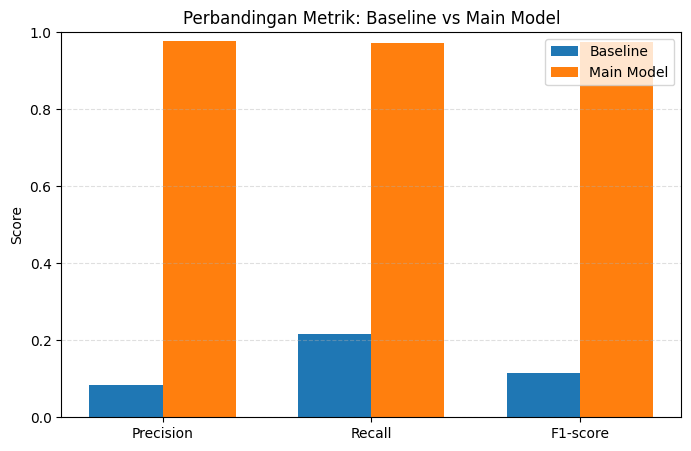

In [ ]:
# =========================
# Cell 17 — Comparison menggunakan Bar Chart
# =========================
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, top_k_accuracy_score

# --- Pastikan y_true ada ---
if 'y_true' not in globals():
    # coba ambil dari val_data jika ada
    try:
        y_true = val_data.classes
    except Exception as e:
        raise RuntimeError("y_true tidak ditemukan dan val_data tidak tersedia. Jalankan evaluasi model terlebih dahulu.") from e

# --- Pastikan prediksi model utama tersedia (y_pred / predictions) ---
if 'y_pred' not in globals() or 'predictions' not in globals():
    try:
        predictions = model.predict(val_data, verbose=0)
        y_pred = np.argmax(predictions, axis=1)
    except Exception as e:
        raise RuntimeError("Gagal menghitung prediksi model utama. Pastikan 'model' dan 'val_data' tersedia.") from e

# --- Pastikan prediksi baseline tersedia (y_pred_b / pred_b / baseline_predictions) ---
if 'y_pred_b' not in globals():
    # coba beberapa nama variabel yang mungkin ada
    if 'pred_b' in globals():
        try:
            y_pred_b = np.argmax(pred_b, axis=1)
        except:
            y_pred_b = None
    elif 'baseline_predictions' in globals():
        try:
            y_pred_b = np.argmax(baseline_predictions, axis=1)
        except:
            y_pred_b = None
    else:
        # jika objek baseline ada, coba prediksi
        if 'baseline' in globals():
            try:
                pred_b = baseline.predict(val_data, verbose=0)
                y_pred_b = np.argmax(pred_b, axis=1)
            except:
                y_pred_b = None
        else:
            y_pred_b = None

# Jika baseline prediksi tetap None, set nilai nol agar plot tetap bisa dibuat (tapi beri peringatan)
if y_pred_b is None:
    print("Peringatan: prediksi baseline tidak tersedia — baseline akan di-skip pada plot.")
    baseline_available = False
else:
    baseline_available = True

# --- Hitung metrik utama (fallback kalau variabel metrik belum ada) ---
if 'main_precision' not in globals() or 'main_recall' not in globals() or 'main_f1' not in globals():
    main_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    main_recall    = recall_score(y_true, y_pred, average='macro', zero_division=0)
    main_f1        = f1_score(y_true, y_pred, average='macro', zero_division=0)

# --- Hitung metrik baseline jika tersedia ---
if baseline_available:
    if 'baseline_precision' not in globals() or 'baseline_recall' not in globals() or 'baseline_f1' not in globals():
        baseline_precision = precision_score(y_true, y_pred_b, average='macro', zero_division=0)
        baseline_recall    = recall_score(y_true, y_pred_b, average='macro', zero_division=0)
        baseline_f1        = f1_score(y_true, y_pred_b, average='macro', zero_division=0)
else:
    baseline_precision = baseline_recall = baseline_f1 = 0.0

# --- Siapkan data untuk plot ---
labels = ["Precision", "Recall", "F1-score"]
baseline_scores = [baseline_precision, baseline_recall, baseline_f1]
main_scores     = [main_precision, main_recall, main_f1]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, baseline_scores, width, label="Baseline" if baseline_available else "Baseline (n/a)")
plt.bar(x + width/2, main_scores, width, label="Main Model")

plt.xticks(x, labels)
plt.ylim(0,1.0)
plt.ylabel("Score")
plt.title("Perbandingan Metrik: Baseline vs Main Model")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

In [ ]:
# =========================
# Save Model
# =========================
model.save('/content/fruit_freshness_multiclass.h5')
print("Model saved.")


Model saved.
